# Model Project

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'--'})
plt.rcParams.update({'font.size': 14})

## 4: Lump-sum taxes and product taxes

### 4.2

#### Calibration: Complements

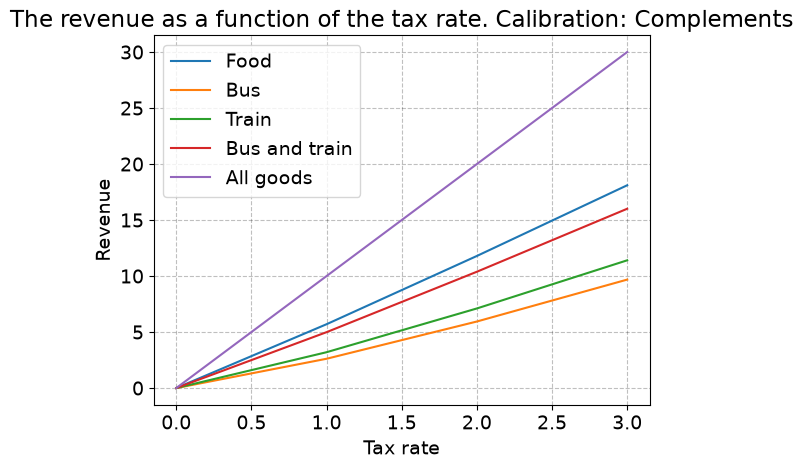

In [9]:
from Government import GovernmentClass

#Only food
food_tax = []
for tau in range(4):   
    gov = GovernmentClass()
    x = gov.revenue_and_utility(tau,(1,))
    food_tax.append(x[0])

#only bus
bus_tax = []
for tau in range(4):   
    gov = GovernmentClass()
    x = gov.revenue_and_utility(tau,(2,))
    bus_tax.append(x[0])

#Only train
train_tax = []
for tau in range(4):   
    gov = GovernmentClass()
    x = gov.revenue_and_utility(tau,(3,))
    train_tax.append(x[0])

#Bus and train tax
bus_and_train_tax = []
for tau in range(4):   
    gov = GovernmentClass()
    x = gov.revenue_and_utility(tau,(2,3))
    bus_and_train_tax.append(x[0])

#Tax on all goods
all_goods_tax = []
for tau in range(4):   
    gov = GovernmentClass()
    x = gov.revenue_and_utility(tau,(1,2,3))
    all_goods_tax.append(x[0])

taxes = [0,1,2,3]

plt.plot(taxes, food_tax, label="Food")
plt.plot(taxes, bus_tax, label="Bus")
plt.plot(taxes, train_tax, label="Train")
plt.plot(taxes, bus_and_train_tax, label="Bus and train")
plt.plot(taxes, all_goods_tax, label="All goods")

plt.xlabel("Tax rate")
plt.ylabel("Revenue")
plt.title("The revenue as a function of the tax rate. Calibration: Complements")

plt.legend(loc="upper left")  # Box
plt.grid(True)
plt.show()

#### Calibration: Substitutes

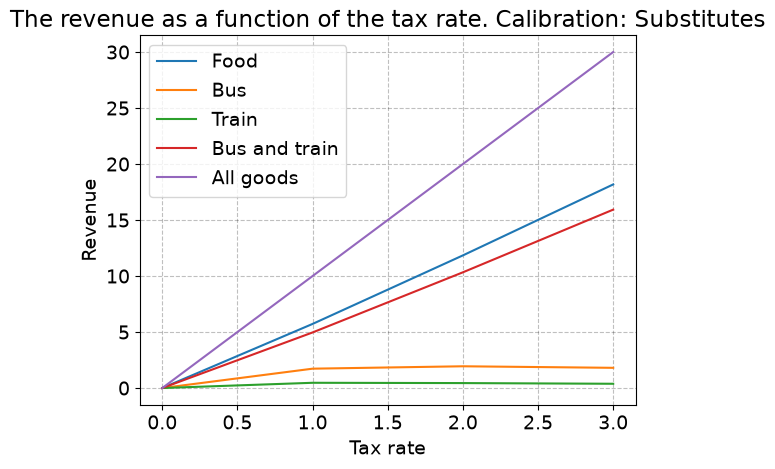

In [10]:
from Government import GovernmentClass

#Changing sigma_B so train and bus are substitutes
model_subtitutes = GovernmentClass(par={"sigma_B":3.0})

#Only food
food_tax = []
for tau in range(4):   
    gov = GovernmentClass()
    x = model_subtitutes.revenue_and_utility(tau,(1,))
    food_tax.append(x[0])

#only bus
bus_tax = []
for tau in range(4):   
    gov = GovernmentClass()
    x = model_subtitutes.revenue_and_utility(tau,(2,))
    bus_tax.append(x[0])

#Only train
train_tax = []
for tau in range(4):   
    gov = GovernmentClass()
    x = model_subtitutes.revenue_and_utility(tau,(3,))
    train_tax.append(x[0])

#Bus and train tax
bus_and_train_tax = []
for tau in range(4):   
    gov = GovernmentClass()
    x = model_subtitutes.revenue_and_utility(tau,(2,3))
    bus_and_train_tax.append(x[0])

#Tax on all goods
all_goods_tax = []
for tau in range(4):   
    gov = GovernmentClass()
    x = model_subtitutes.revenue_and_utility(tau,(1,2,3))
    all_goods_tax.append(x[0])

taxes = [0,1,2,3]

plt.plot(taxes, food_tax, label="Food")
plt.plot(taxes, bus_tax, label="Bus")
plt.plot(taxes, train_tax, label="Train")
plt.plot(taxes, bus_and_train_tax, label="Bus and train")
plt.plot(taxes, all_goods_tax, label="All goods")

plt.xlabel("Tax rate")
plt.ylabel("Revenue")
plt.title("The revenue as a function of the tax rate. Calibration: Substitutes")

plt.legend(loc="upper left")  # Box
plt.grid(True)
plt.show()


### 4.3

Which of the curves have a top and which just keep rising?

The curves which represent tax on the bus and tax on the train have a top in the case where bus and train are substitutes. The other curves are rising in the case with bus and train as substitutes. In the case where bus and train are complements all curves continues rising.

In [11]:
# The revenue-maximizing rate and the largest possible revenue where there is a top.
gor = GovernmentClass(par={"sigma_B":3.0})

#train_max = optimize.minimize(gor.revenue_and_utility(tau,(3,)), 0,method='L-BFGS-B', bounds=(0,3))

train_max = optimize.minimize_scalar(lambda tau: -gor.revenue_and_utility(tau, (3,))[0], bounds=(0, 3), method="bounded")

tau_optimal = train_max.x
max_revenue = -train_max.fun

print("Optimal tau:", tau_optimal)
print("Max revenue:", max_revenue)

print(train_max)

Optimal tau: 1.211601085618209
Max revenue: 0.47308802647981996
 message: Solution found.
 success: True
  status: 0
     fun: -0.47308802647981996
       x: 1.211601085618209
     nit: 21
    nfev: 21


As seen in the calculations above, the optimal tax on the train tickets is 1.212 which gives a revenue of 0.473

### 4.4

#### Calibration: Complements

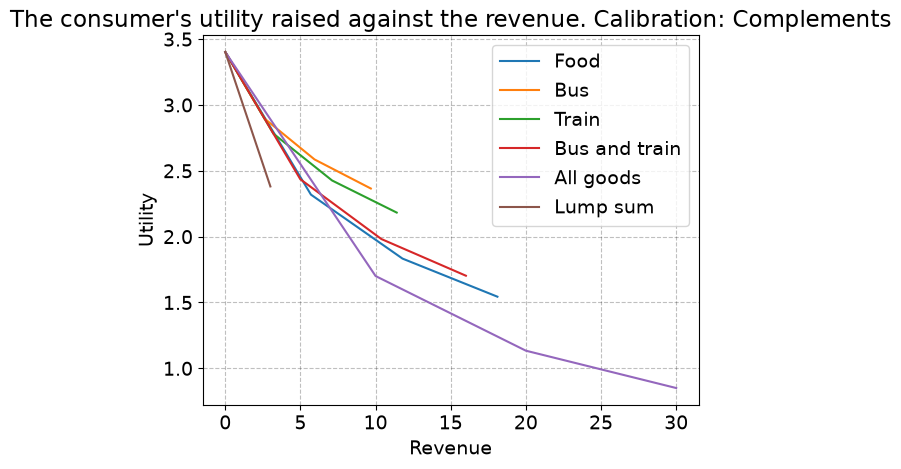

In [12]:
from Government import GovernmentClass

#Only food
food_rev = []
food_util = []
for tau in range(4):   
    gov = GovernmentClass()
    R,u = gov.revenue_and_utility(tau,(1,))
    food_rev.append(R)
    food_util.append(u)

#only bus
bus_rev = []
bus_util = []
for tau in range(4):   
    gov = GovernmentClass()
    R, u = gov.revenue_and_utility(tau,(2,))
    bus_rev.append(R)
    bus_util.append(u)

#Only train
train_rev = []
train_util = []
for tau in range(4):   
    gov = GovernmentClass()
    R, u = gov.revenue_and_utility(tau,(3,))
    train_rev.append(R)
    train_util.append(u)

#Bus and train tax
bus_and_train_rev = []
bus_and_train_util = []
for tau in range(4):   
    gov = GovernmentClass()
    R, u = gov.revenue_and_utility(tau,(2,3))
    bus_and_train_rev.append(R)
    bus_and_train_util.append(u)

#Tax on all goods
all_goods_rev = []
all_goods_util = []
for tau in range(4):   
    gov = GovernmentClass()
    R, u = gov.revenue_and_utility(tau,(1,2,3))
    all_goods_rev.append(R)
    all_goods_util.append(u)

#Lump sump
lump_sum_rev = []
lump_sum_util = []
for T in range(4):
    gov = GovernmentClass()
    R, u = gov.revenue_and_utility_lump_sum(T)
    lump_sum_rev.append(R)
    lump_sum_util.append(u)

#Plotting the graph
plt.plot(food_rev, food_util, label="Food")
plt.plot(bus_rev, bus_util, label="Bus")
plt.plot(train_rev, train_util, label="Train")
plt.plot(bus_and_train_rev, bus_and_train_util, label="Bus and train")
plt.plot(all_goods_rev, all_goods_util, label="All goods")
plt.plot(lump_sum_rev, lump_sum_util, label="Lump sum")

plt.xlabel("Revenue")
plt.ylabel("Utility")
plt.title("The consumer's utility raised against the revenue. Calibration: Complements")

plt.legend(loc="upper right")  # Box
plt.grid(True)
plt.show()

#### Calibration: Substitutes

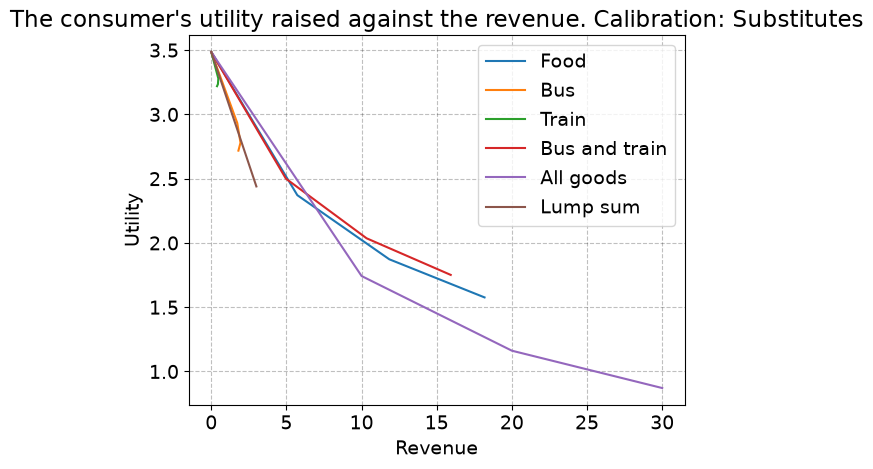

In [13]:
from Government import GovernmentClass

#Only food
food_rev = []
food_util = []
for tau in range(4):   
    gov = GovernmentClass(par={"sigma_B":3.0})
    R,u = gov.revenue_and_utility(tau,(1,))
    food_rev.append(R)
    food_util.append(u)

#only bus
bus_rev = []
bus_util = []
for tau in range(4):   
    gov = GovernmentClass(par={"sigma_B":3.0})
    R, u = gov.revenue_and_utility(tau,(2,))
    bus_rev.append(R)
    bus_util.append(u)

#Only train
train_rev = []
train_util = []
for tau in range(4):   
    gov = GovernmentClass(par={"sigma_B":3.0})
    R, u = gov.revenue_and_utility(tau,(3,))
    train_rev.append(R)
    train_util.append(u)

#Bus and train tax
bus_and_train_rev = []
bus_and_train_util = []
for tau in range(4):   
    gov = GovernmentClass(par={"sigma_B":3.0})
    R, u = gov.revenue_and_utility(tau,(2,3))
    bus_and_train_rev.append(R)
    bus_and_train_util.append(u)

#Tax on all goods
all_goods_rev = []
all_goods_util = []
for tau in range(4):   
    gov = GovernmentClass(par={"sigma_B":3.0})
    R, u = gov.revenue_and_utility(tau,(1,2,3))
    all_goods_rev.append(R)
    all_goods_util.append(u)

#Lump sump
lump_sum_rev = []
lump_sum_util = []
for T in range(4):
    gov = GovernmentClass(par={"sigma_B":3.0})
    R, u = gov.revenue_and_utility_lump_sum(T)
    lump_sum_rev.append(R)
    lump_sum_util.append(u)

#Plotting the graph
plt.plot(food_rev, food_util, label="Food")
plt.plot(bus_rev, bus_util, label="Bus")
plt.plot(train_rev, train_util, label="Train")
plt.plot(bus_and_train_rev, bus_and_train_util, label="Bus and train")
plt.plot(all_goods_rev, all_goods_util, label="All goods")
plt.plot(lump_sum_rev, lump_sum_util, label="Lump sum")

plt.xlabel("Revenue")
plt.ylabel("Utility")
plt.title("The consumer's utility raised against the revenue. Calibration: Substitutes")

plt.legend(loc="upper right")  # Box
plt.grid(True)
plt.show()

Which instrument is the cheapest way to raise a given revenue, and does the ranking depend on the calibration?
When bus and train are substitutes the cheapest solution is to set the product tax on bus and train together. This curve, which is colored red in this case, are the one lying most in the upper right corner which means that for a given revenue, the utility is higher.
When bus and train are complements it is cheapest to put the the product tax on bus tickets.
For both cases the lump sum tax is a expensive way to tax the consumer. A reason for this might be that the consumer cannot change their liability.

### 4.5

#### Calibration: Complements

In [14]:
from Government import GovernmentClass
import pandas as pd

gov = GovernmentClass()

R_target = 0.02

#Food
tau_food = gov.find_tax_rate(
    R_target,
    goods=(1,),
    bracket=(1e-10, 1.0)
)

R_food, u_food = gov.revenue_and_utility(tau_food, goods=(1,))

print(f"tau_food = {tau_food:.6f}")
print(f"Revenue_food = {R_food:.6f}")
print(f"Utility_food = {u_food:.6f}")

#Bus
tau_bus = gov.find_tax_rate(
    R_target,
    goods=(2,),
    bracket=(1e-10, 1.0)
)

R_bus, u_bus = gov.revenue_and_utility(tau_bus, goods=(2,))

print(f"tau_bus = {tau_bus:.6f}")
print(f"Revenue_bus = {R_bus:.6f}")
print(f"Utility_bus = {u_bus:.6f}")

#Train
tau_train = gov.find_tax_rate(
    R_target,
    goods=(3,),
    bracket=(1e-10, 1.0)
)

R_train, u_train = gov.revenue_and_utility(tau_train, goods=(2,))

print(f"tau_train = {tau_train:.6f}")
print(f"Revenue_train = {R_train:.6f}")
print(f"Utility_train = {u_train:.6f}")

#Bus and train
tau_bus_and_train = gov.find_tax_rate(
    R_target,
    goods=(2,3),
    bracket=(1e-10, 1.0)
)

R_bus_and_train, u_bus_and_train = gov.revenue_and_utility(tau_bus_and_train, goods=(2,3))

print(f"tau_bus_and_train = {tau_bus_and_train:.6f}")
print(f"Revenue_bus_and_train = {R_bus_and_train:.6f}")
print(f"Utility_bus_and_train = {u_bus_and_train:.6f}")

#All goods
tau_all_goods = gov.find_tax_rate(
    R_target,
    goods=(1,2,3),
    bracket=(1e-10, 1.0)
)

R_all_goods, u_all_goods = gov.revenue_and_utility(tau_all_goods, goods=(1,2,3))

print(f"tau_all_goods = {tau_all_goods:.6f}")
print(f"Revenue_all_goods = {R_all_goods:.6f}")
print(f"Utility_all_goods = {u_all_goods:.6f}")

import pandas as pd

data = {
    "Tax": [
        "Food",
        "Bus",
        "Train",
        "Bus and Train",
        "All goods"
    ],
    "Tax rate": [
        tau_food,
        tau_bus,
        tau_train,
        tau_bus_and_train,
        tau_all_goods
    ],
    "Revenue": [
        R_food,
        R_bus,
        R_train,
        R_bus_and_train,
        R_all_goods
    ],
    "Utility": [
        u_food,
        u_bus,
        u_train,
        u_bus_and_train,
        u_all_goods
    ]
}

df = pd.DataFrame(data)

df

tau_food = 0.003733
Revenue_food = 0.020000
Utility_food = 3.394897
tau_bus = 0.009763
Revenue_bus = 0.020000
Utility_bus = 3.394929
tau_train = 0.007665
Revenue_train = 0.015688
Utility_train = 3.396376
tau_bus_and_train = 0.004305
Revenue_bus_and_train = 0.020000
Utility_bus_and_train = 3.394899
tau_all_goods = 0.002000
Revenue_all_goods = 0.020000
Utility_all_goods = 3.394890


,Tax,Tax rate,Revenue,Utility
0,Food,0.003733,0.020000,3.394897
1,Bus,0.009763,0.020000,3.394929
2,Train,0.007665,0.015688,3.396376
3,Bus and Train,0.004305,0.020000,3.394899
4,All goods,0.002000,0.020000,3.394890


#### Calibration: Substitutes

In [15]:
from Government import GovernmentClass

gov = GovernmentClass(par={"sigma_B":3.0})

R_target = 0.02

#Food
tau_food = gov.find_tax_rate(
    R_target,
    goods=(1,),
    bracket=(1e-10, 1.0)
)

R_food, u_food = gov.revenue_and_utility(tau_food, goods=(1,))

print(f"tau_food = {tau_food:.6f}")
print(f"Revenue_food = {R_food:.6f}")
print(f"Utility_food = {u_food:.6f}")

#Bus
tau_bus = gov.find_tax_rate(
    R_target,
    goods=(2,),
    bracket=(1e-10, 1.0)
)

R_bus, u_bus = gov.revenue_and_utility(tau_bus, goods=(2,))

print(f"tau_bus = {tau_bus:.6f}")
print(f"Revenue_bus = {R_bus:.6f}")
print(f"Utility_bus = {u_bus:.6f}")

#Train
tau_train = gov.find_tax_rate(
    R_target,
    goods=(3,),
    bracket=(1e-10, 1.0)
)

R_train, u_train = gov.revenue_and_utility(tau_train, goods=(2,))

print(f"tau_train = {tau_train:.6f}")
print(f"Revenue_train = {R_train:.6f}")
print(f"Utility_train = {u_train:.6f}")

#Bus and train
tau_bus_and_train = gov.find_tax_rate(
    R_target,
    goods=(2,3),
    bracket=(1e-10, 1.0)
)

R_bus_and_train, u_bus_and_train = gov.revenue_and_utility(tau_bus_and_train, goods=(2,3))

print(f"tau_bus_and_train = {tau_bus_and_train:.6f}")
print(f"Revenue_bus_and_train = {R_bus_and_train:.6f}")
print(f"Utility_bus_and_train = {u_bus_and_train:.6f}")

#All goods
tau_all_goods = gov.find_tax_rate(
    R_target,
    goods=(1,2,3),
    bracket=(1e-10, 1.0)
)

R_all_goods, u_all_goods = gov.revenue_and_utility(tau_all_goods, goods=(1,2,3))

print(f"tau_all_goods = {tau_all_goods:.6f}")
print(f"Revenue_all_goods = {R_all_goods:.6f}")
print(f"Utility_all_goods = {u_all_goods:.6f}")

import pandas as pd

data = {
    "Tax": [
        "Food",
        "Bus",
        "Train",
        "Bus and Train",
        "All goods"
    ],
    "Tax rate": [
        tau_food,
        tau_bus,
        tau_train,
        tau_bus_and_train,
        tau_all_goods
    ],
    "Revenue": [
        R_food,
        R_bus,
        R_train,
        R_bus_and_train,
        R_all_goods
    ],
    "Utility": [
        u_food,
        u_bus,
        u_train,
        u_bus_and_train,
        u_all_goods
    ]
}

df = pd.DataFrame(data)

df

tau_food = 0.003715
Revenue_food = 0.020000
Utility_food = 3.478155
tau_bus = 0.006277
Revenue_bus = 0.020000
Utility_bus = 3.478151
tau_train = 0.014351
Revenue_train = 0.045523
Utility_train = 3.469326
tau_bus_and_train = 0.004329
Revenue_bus_and_train = 0.020000
Utility_bus_and_train = 3.478158
tau_all_goods = 0.002000
Revenue_all_goods = 0.020000
Utility_all_goods = 3.478148


,Tax,Tax rate,Revenue,Utility
0,Food,0.003715,0.020000,3.478155
1,Bus,0.006277,0.020000,3.478151
2,Train,0.014351,0.045523,3.469326
3,Bus and Train,0.004329,0.020000,3.478158
4,All goods,0.002000,0.020000,3.478148


The revenue on the train ticket differs from 0.02 in both cases. When bus and train are complements, the revenue on the train is less than 0.02. In the other case where bus and train are substitutes, the revenue on the train tickets are larger.
To rank the instruments, the instrument with the highest utility wins. In the case with bus and train as complements, the train tickets gives highest utility. After the train it is the bus tickets.
In the case where bus and train are substitutes, bus and train together gives the highest utility.